In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel(r"C:\Users\HP\OneDrive\Documents\My Projects\COVID-19-Data-Analysis\covid-data.xlsx")

In [3]:
df.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index
0,AFG,Asia,Afghanistan,2020-02-24,1.0,1.0,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
1,AFG,Asia,Afghanistan,2020-02-25,1.0,0.0,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
2,AFG,Asia,Afghanistan,2020-02-26,1.0,0.0,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
3,AFG,Asia,Afghanistan,2020-02-27,1.0,0.0,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
4,AFG,Asia,Afghanistan,2020-02-28,1.0,0.0,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511


In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (91026, 59)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91026 entries, 0 to 91025
Data columns (total 59 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   iso_code                               91026 non-null  object 
 1   continent                              86699 non-null  object 
 2   location                               91026 non-null  object 
 3   date                                   91026 non-null  object 
 4   total_cases                            88336 non-null  float64
 5   new_cases                              88335 non-null  float64
 6   new_cases_smoothed                     87328 non-null  float64
 7   total_deaths                           78484 non-null  float64
 8   new_deaths                             78642 non-null  float64
 9   new_deaths_smoothed                    87328 non-null  float64
 10  total_cases_per_million                87863 non-null  float64
 11  ne

In [6]:
print(df.columns.tolist())

['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases', 'new_cases_smoothed', 'total_deaths', 'new_deaths', 'new_deaths_smoothed', 'total_cases_per_million', 'new_cases_per_million', 'new_cases_smoothed_per_million', 'total_deaths_per_million', 'new_deaths_per_million', 'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients', 'icu_patients_per_million', 'hosp_patients', 'hosp_patients_per_million', 'weekly_icu_admissions', 'weekly_icu_admissions_per_million', 'weekly_hosp_admissions', 'weekly_hosp_admissions_per_million', 'new_tests', 'total_tests', 'total_tests_per_thousand', 'new_tests_per_thousand', 'new_tests_smoothed', 'new_tests_smoothed_per_thousand', 'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated', 'new_vaccinations', 'new_vaccinations_smoothed', 'total_vaccinations_per_hundred', 'people_vaccinated_per_hundred', 'people_fully_vaccinated_per_hundred', 'new_vaccinations_smoothe

In [7]:
df.describe()

,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths_per_million,...,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index
count,8.833600e+04,88335.000000,87328.000000,7.848400e+04,78642.000000,87328.000000,87863.000000,87862.000000,86860.000000,78024.000000,...,81972.000000,55479.000000,82163.000000,84019.000000,64338.000000,63393.000000,41288.000000,74934.000000,86432.000000,82351.000000
mean,9.151563e+05,6033.622743,6046.602763,2.479388e+04,141.643664,126.433556,11220.125030,75.755854,75.892982,245.707748,...,19296.887209,13.373408,258.044821,7.876693,10.537168,32.666667,50.881769,3.029373,73.231286,0.727804
std,6.322927e+06,38089.918376,37733.973544,1.476747e+05,777.835074,717.118005,21227.092043,196.149038,155.744273,429.926840,...,19954.883034,19.951487,118.858771,4.062795,10.425066,13.472618,31.761800,2.461568,7.564003,0.150413
min,1.000000e+00,-74347.000000,-6223.000000,1.000000e+00,-1918.000000,-232.143000,0.001000,-2153.437000,-276.825000,0.001000,...,661.240000,0.100000,79.370000,0.990000,0.100000,7.700000,1.188000,0.100000,53.280000,0.394000
25%,1.055000e+03,2.000000,7.143000,4.800000e+01,0.000000,0.000000,220.891500,0.202000,1.212750,7.296750,...,4466.507000,0.600000,167.295000,5.310000,1.900000,21.600000,20.859000,1.300000,67.920000,0.602000
50%,1.161100e+04,70.000000,87.286000,3.330000e+02,2.000000,1.286000,1514.078000,7.846000,10.428000,43.718000,...,12951.839000,2.200000,242.648000,7.110000,6.300000,31.400000,49.839000,2.400000,74.620000,0.748000
75%,1.232172e+05,783.000000,819.714000,3.229250e+03,18.000000,14.000000,11074.352500,70.163500,78.714500,267.625250,...,27216.445000,21.200000,329.635000,10.080000,19.300000,41.100000,83.241000,3.861000,78.740000,0.848000
max,1.673164e+08,905992.000000,826374.286000,3.473036e+06,17906.000000,14436.286000,175616.385000,18293.675000,4083.500000,3059.931000,...,116935.600000,77.600000,724.417000,30.530000,44.000000,78.100000,100.000000,13.800000,86.750000,0.957000


In [8]:
df.describe(include="all")

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index
count,91026,86699,91026,91026,8.833600e+04,88335.000000,87328.000000,7.848400e+04,78642.000000,87328.000000,...,81972.000000,55479.000000,82163.000000,84019.000000,64338.000000,63393.000000,41288.000000,74934.000000,86432.000000,82351.000000
unique,226,6,226,511,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,MEX,Africa,Mexico,2021-04-27,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,510,23577,510,222,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,9.151563e+05,6033.622743,6046.602763,2.479388e+04,141.643664,126.433556,...,19296.887209,13.373408,258.044821,7.876693,10.537168,32.666667,50.881769,3.029373,73.231286,0.727804
std,NaN,NaN,NaN,NaN,6.322927e+06,38089.918376,37733.973544,1.476747e+05,777.835074,717.118005,...,19954.883034,19.951487,118.858771,4.062795,10.425066,13.472618,31.761800,2.461568,7.564003,0.150413
min,NaN,NaN,NaN,NaN,1.000000e+00,-74347.000000,-6223.000000,1.000000e+00,-1918.000000,-232.143000,...,661.240000,0.100000,79.370000,0.990000,0.100000,7.700000,1.188000,0.100000,53.280000,0.394000
25%,NaN,NaN,NaN,NaN,1.055000e+03,2.000000,7.143000,4.800000e+01,0.000000,0.000000,...,4466.507000,0.600000,167.295000,5.310000,1.900000,21.600000,20.859000,1.300000,67.920000,0.602000
50%,NaN,NaN,NaN,NaN,1.161100e+04,70.000000,87.286000,3.330000e+02,2.000000,1.286000,...,12951.839000,2.200000,242.648000,7.110000,6.300000,31.400000,49.839000,2.400000,74.620000,0.748000
75%,NaN,NaN,NaN,NaN,1.232172e+05,783.000000,819.714000,3.229250e+03,18.000000,14.000000,...,27216.445000,21.200000,329.635000,10.080000,19.300000,41.100000,83.241000,3.861000,78.740000,0.848000


### Check Missing Values

In [9]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

weekly_icu_admissions_per_million        90196
weekly_icu_admissions                    90196
weekly_hosp_admissions_per_million       89580
weekly_hosp_admissions                   89580
people_fully_vaccinated_per_hundred      82259
people_fully_vaccinated                  82259
icu_patients                             81850
icu_patients_per_million                 81850
new_vaccinations                         80842
people_vaccinated_per_hundred            79673
people_vaccinated                        79673
hosp_patients_per_million                79611
hosp_patients                            79611
total_vaccinations                       78920
total_vaccinations_per_hundred           78920
new_vaccinations_smoothed                70489
new_vaccinations_smoothed_per_million    70489
total_tests                              50153
total_tests_per_thousand                 50153
new_tests_per_thousand                   49840
new_tests                                49840
handwashing_f

In [10]:
print("Total missing values in dataset:", df.isnull().sum().sum())

Total missing values in dataset: 2152143


In [11]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [12]:
df.dtypes

iso_code                                  object
continent                                 object
location                                  object
date                                      object
total_cases                              float64
new_cases                                float64
new_cases_smoothed                       float64
total_deaths                             float64
new_deaths                               float64
new_deaths_smoothed                      float64
total_cases_per_million                  float64
new_cases_per_million                    float64
new_cases_smoothed_per_million           float64
total_deaths_per_million                 float64
new_deaths_per_million                   float64
new_deaths_smoothed_per_million          float64
reproduction_rate                        float64
icu_patients                             float64
icu_patients_per_million                 float64
hosp_patients                            float64
hosp_patients_per_mi

### Check Important Unique Values

In [13]:
print("Number of unique locations:", df["location"].nunique())

print("\nSample locations:")
print(df["location"].unique()[:20])

Number of unique locations: 226

Sample locations:
['Afghanistan' 'Africa' 'Albania' 'Algeria' 'Andorra' 'Angola' 'Anguilla'
 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Aruba' 'Asia' 'Australia'
 'Austria' 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh' 'Barbados'
 'Belarus']


In [14]:
print(df["continent"].value_counts(dropna=False))

continent
Africa           23577
Asia             21744
Europe           21643
North America    11081
South America     5523
NaN               4327
Oceania           3131
Name: count, dtype: int64


### Select Relevant Columns

In [15]:
selected_columns = [
    "iso_code",
    "continent",
    "location",
    "date",
    "total_cases",
    "new_cases",
    "total_deaths",
    "new_deaths",
    "total_tests",
    "new_tests",
    "positive_rate",
    "tests_per_case",
    "total_vaccinations",
    "people_vaccinated",
    "people_fully_vaccinated",
    "new_vaccinations",
    "icu_patients",
    "hosp_patients",
    "population",
    "population_density",
    "median_age",
    "aged_65_older",
    "gdp_per_capita",
    "hospital_beds_per_thousand",
    "life_expectancy"
]

covid_df = df[selected_columns].copy()

print("New dataset shape:", covid_df.shape)

New dataset shape: (91026, 25)


In [16]:
missing_selected = covid_df.isnull().sum()

missing_selected[missing_selected > 0].sort_values(ascending=False)

people_fully_vaccinated       82259
icu_patients                  81850
new_vaccinations              80842
people_vaccinated             79673
hosp_patients                 79611
total_vaccinations            78920
total_tests                   50153
new_tests                     49840
tests_per_case                47176
positive_rate                 46582
hospital_beds_per_thousand    16092
total_deaths                  12542
new_deaths                    12384
aged_65_older                 10197
median_age                     9273
gdp_per_capita                 9054
population_density             6364
life_expectancy                4594
continent                      4327
new_cases                      2691
total_cases                    2690
population                      604
dtype: int64

In [17]:
print("Duplicate rows before cleaning:", covid_df.duplicated().sum())

Duplicate rows before cleaning: 0


### Handle Aggregate Locations

In [18]:
covid_df = covid_df.dropna(subset=["continent"]).copy()

print("Dataset shape after removing aggregate locations:", covid_df.shape)

Dataset shape after removing aggregate locations: (86699, 25)


In [19]:
print("Missing continent values:", covid_df["continent"].isnull().sum())

Missing continent values: 0


### Convert the Date Column

In [20]:
covid_df["date"] = pd.to_datetime(covid_df["date"])

print(covid_df["date"].dtype)

datetime64[ns]


In [21]:
essential_columns = [
    "location",
    "date",
    "population"
]

print(covid_df[essential_columns].isnull().sum())

location        0
date            0
population    131
dtype: int64


In [22]:
print(covid_df["continent"].value_counts(dropna=False))

continent
Africa           23577
Asia             21744
Europe           21643
North America    11081
South America     5523
Oceania           3131
Name: count, dtype: int64


In [23]:
print("Missing continent values before cleaning:")
print(covid_df["continent"].isnull().sum())

covid_df = covid_df.dropna(subset=["continent"]).copy()

print("\nMissing continent values after cleaning:")
print(covid_df["continent"].isnull().sum())

print("\nUnique locations after removing aggregate records:")
print(covid_df["location"].nunique())

Missing continent values before cleaning:
0

Missing continent values after cleaning:
0

Unique locations after removing aggregate records:
217


### Remove Aggregate Locations

In [24]:
print("Shape before removing aggregate records:", covid_df.shape)

covid_df = covid_df.dropna(subset=["continent"]).copy()

print("Shape after removing aggregate records:", covid_df.shape)

print("\nMissing continent values:")
print(covid_df["continent"].isnull().sum())

print("\nNumber of unique locations:")
print(covid_df["location"].nunique())

Shape before removing aggregate records: (86699, 25)
Shape after removing aggregate records: (86699, 25)

Missing continent values:
0

Number of unique locations:
217


In [25]:
print(covid_df["location"].unique())

['Afghanistan' 'Albania' 'Algeria' 'Andorra' 'Angola' 'Anguilla'
 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Aruba' 'Australia' 'Austria'
 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus'
 'Belgium' 'Belize' 'Benin' 'Bermuda' 'Bhutan' 'Bolivia'
 'Bonaire Sint Eustatius and Saba' 'Bosnia and Herzegovina' 'Botswana'
 'Brazil' 'Brunei' 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cambodia'
 'Cameroon' 'Canada' 'Cape Verde' 'Cayman Islands'
 'Central African Republic' 'Chad' 'Chile' 'China' 'Colombia' 'Comoros'
 'Congo' 'Costa Rica' "Cote d'Ivoire" 'Croatia' 'Cuba' 'Curacao' 'Cyprus'
 'Czechia' 'Democratic Republic of Congo' 'Denmark' 'Djibouti' 'Dominica'
 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador' 'Equatorial Guinea'
 'Eritrea' 'Estonia' 'Eswatini' 'Ethiopia' 'Faeroe Islands'
 'Falkland Islands' 'Fiji' 'Finland' 'France' 'French Polynesia' 'Gabon'
 'Gambia' 'Georgia' 'Germany' 'Ghana' 'Gibraltar' 'Greece' 'Greenland'
 'Grenada' 'Guatemala' 'Guernsey' 'Guinea' 'Guine

### Check Duplicate Rows

In [28]:
print("Duplicate rows:", covid_df.duplicated().sum())

Duplicate rows: 0


In [29]:
duplicate_location_date = covid_df.duplicated(
    subset=["location", "date"]
).sum()

print("Duplicate location-date records:", duplicate_location_date)

Duplicate location-date records: 0


### Check Negative Values

In [30]:
columns_to_check = [
    "total_cases",
    "new_cases",
    "total_deaths",
    "new_deaths",
    "total_tests",
    "new_tests",
    "total_vaccinations",
    "people_vaccinated",
    "people_fully_vaccinated",
    "new_vaccinations",
    "icu_patients",
    "hosp_patients",
    "population"
]

negative_counts = {}

for column in columns_to_check:
    negative_counts[column] = (covid_df[column] < 0).sum()

negative_counts

{'total_cases': np.int64(0),
 'new_cases': np.int64(65),
 'total_deaths': np.int64(0),
 'new_deaths': np.int64(82),
 'total_tests': np.int64(0),
 'new_tests': np.int64(13),
 'total_vaccinations': np.int64(0),
 'people_vaccinated': np.int64(0),
 'people_fully_vaccinated': np.int64(0),
 'new_vaccinations': np.int64(0),
 'icu_patients': np.int64(0),
 'hosp_patients': np.int64(0),
 'population': np.int64(0)}

In [31]:
daily_columns = [
    "new_cases",
    "new_deaths",
    "new_tests"
]

for column in daily_columns:
    covid_df.loc[covid_df[column] < 0, column] = np.nan

In [32]:
for column in daily_columns:
    print(f"{column}: {(covid_df[column] < 0).sum()} negative values remaining")

new_cases: 0 negative values remaining
new_deaths: 0 negative values remaining
new_tests: 0 negative values remaining


In [33]:
missing_after_cleaning = covid_df.isnull().sum()

missing_after_cleaning[missing_after_cleaning > 0].sort_values(ascending=False)

people_fully_vaccinated       79000
new_vaccinations              77695
icu_patients                  77523
people_vaccinated             76543
total_vaccinations            75790
hosp_patients                 75284
total_tests                   45826
new_tests                     45526
tests_per_case                42849
positive_rate                 42255
new_deaths                    12453
total_deaths                  12370
hospital_beds_per_thousand    12254
aged_65_older                  6359
median_age                     5435
gdp_per_capita                 5216
new_cases                      2756
total_cases                    2685
population_density             2526
life_expectancy                 756
population                      131
dtype: int64

### Check Date Range

In [34]:
print("Minimum date:", covid_df["date"].min())
print("Maximum date:", covid_df["date"].max())

Minimum date: 2020-01-01 00:00:00
Maximum date: 2021-05-25 00:00:00


In [35]:
covid_df["year"] = covid_df["date"].dt.year

print(covid_df["year"].value_counts().sort_index())

year
2020    57069
2021    29630
Name: count, dtype: int64


In [36]:
print("Missing population values:", covid_df["population"].isnull().sum())
print("Zero population values:", (covid_df["population"] == 0).sum())
print("Negative population values:", (covid_df["population"] < 0).sum())

Missing population values: 131
Zero population values: 0
Negative population values: 0


In [38]:
records_per_location = covid_df.groupby("location").size()

print(records_per_location.describe())

count    217.000000
mean     399.534562
std      126.284218
min        1.000000
25%      431.000000
50%      441.000000
75%      455.000000
max      510.000000
dtype: float64


In [39]:
print(records_per_location.sort_values().head(10))

location
Tuvalu                              1
Turkmenistan                        1
Bonaire Sint Eustatius and Saba     1
Sint Maarten (Dutch part)          15
Tonga                              29
Nauru                              41
Curacao                            57
Aruba                              57
Wallis and Futuna                  57
Falkland Islands                   67
dtype: int64


In [40]:
covid_df = covid_df.sort_values(
    by=["location", "date"]
).reset_index(drop=True)

### Create Death Rate (%)

In [42]:
covid_df["death_rate"] = (
    covid_df["total_deaths"] / covid_df["total_cases"]
) * 100

In [44]:
covid_df["death_rate"] = covid_df["death_rate"].replace(
    [np.inf, -np.inf],
    np.nan
)

### Create Vaccination Rate (%)

In [45]:
covid_df["vaccination_rate"] = (
    covid_df["people_fully_vaccinated"] / covid_df["population"]
) * 100

### Create Cases per 100,000 Population

In [46]:
covid_df["cases_per_100k"] = (
    covid_df["total_cases"] / covid_df["population"]
) * 100000

### Create Deaths per 100,000 Population

In [47]:
covid_df["deaths_per_100k"] = (
    covid_df["total_deaths"] / covid_df["population"]
) * 100000

### Clean infinite values from all calculated columns

In [48]:
new_columns = [
    "death_rate",
    "vaccination_rate",
    "cases_per_100k",
    "deaths_per_100k"
]

covid_df[new_columns] = covid_df[new_columns].replace(
    [np.inf, -np.inf],
    np.nan
)

### Check the new columns

In [49]:
covid_df[
    [
        "location",
        "date",
        "total_cases",
        "total_deaths",
        "population",
        "death_rate",
        "vaccination_rate",
        "cases_per_100k",
        "deaths_per_100k"
    ]
].head()

,location,date,total_cases,total_deaths,population,death_rate,vaccination_rate,cases_per_100k,deaths_per_100k
0,Afghanistan,2020-02-24,1.0,NaN,38928341.0,NaN,NaN,0.002569,NaN
1,Afghanistan,2020-02-25,1.0,NaN,38928341.0,NaN,NaN,0.002569,NaN
2,Afghanistan,2020-02-26,1.0,NaN,38928341.0,NaN,NaN,0.002569,NaN
3,Afghanistan,2020-02-27,1.0,NaN,38928341.0,NaN,NaN,0.002569,NaN
4,Afghanistan,2020-02-28,1.0,NaN,38928341.0,NaN,NaN,0.002569,NaN


### Basic Overview of the Cleaned Dataset

In [50]:
print("Final Dataset Shape:", covid_df.shape)

print("\nColumns:")
print(covid_df.columns.tolist())

Final Dataset Shape: (86699, 30)

Columns:
['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases', 'total_deaths', 'new_deaths', 'total_tests', 'new_tests', 'positive_rate', 'tests_per_case', 'total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated', 'new_vaccinations', 'icu_patients', 'hosp_patients', 'population', 'population_density', 'median_age', 'aged_65_older', 'gdp_per_capita', 'hospital_beds_per_thousand', 'life_expectancy', 'year', 'death_rate', 'vaccination_rate', 'cases_per_100k', 'deaths_per_100k']


In [51]:
covid_df[
    [
        "death_rate",
        "vaccination_rate",
        "cases_per_100k",
        "deaths_per_100k"
    ]
].describe()

,death_rate,vaccination_rate,cases_per_100k,deaths_per_100k
count,74328.000000,7687.000000,84014.000000,74329.000000
mean,2.847874,7.080168,1117.557915,24.131654
std,3.460704,11.363936,2134.710522,42.914210
min,0.042128,0.000002,0.000072,0.000072
25%,1.181513,0.761068,21.428594,0.700126
50%,1.973684,2.989532,146.461121,4.084634
75%,3.267687,8.305243,1093.321036,25.131558
max,100.000000,110.412276,17561.638517,305.993054


### Global COVID-19 Trend Over Time

In [52]:
global_daily = covid_df.groupby("date").agg(
    new_cases=("new_cases", "sum"),
    new_deaths=("new_deaths", "sum")
).reset_index()

global_daily.head()

,date,new_cases,new_deaths
0,2020-01-01,0.0,0.0
1,2020-01-02,0.0,0.0
2,2020-01-03,0.0,0.0
3,2020-01-04,0.0,0.0
4,2020-01-05,0.0,0.0


### Create a Cases Trend Graph

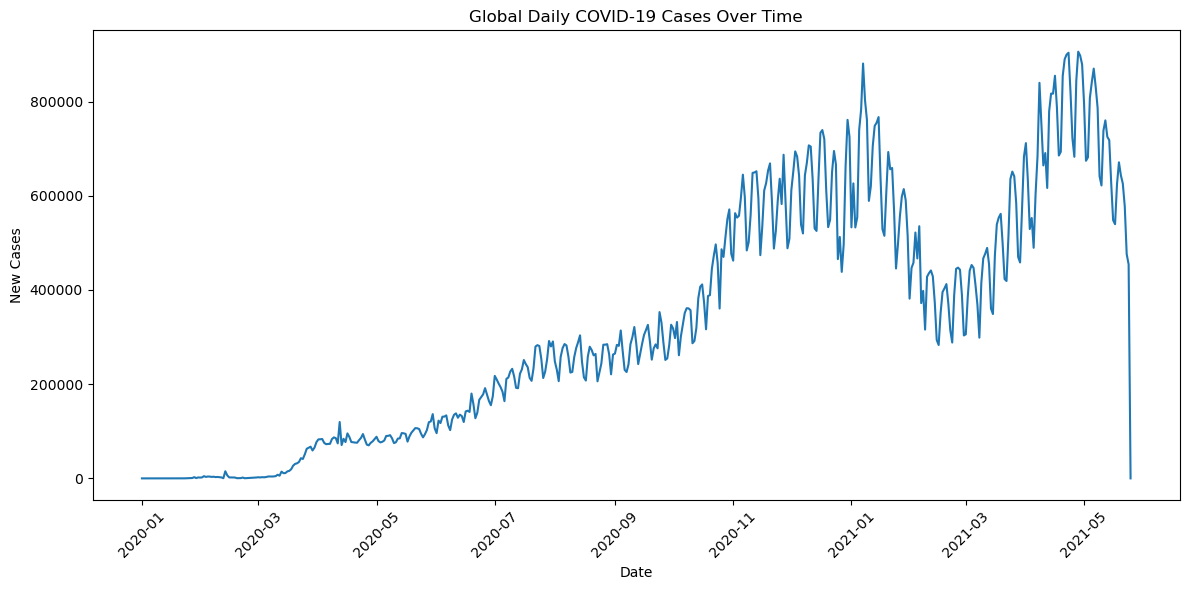

In [53]:
plt.figure(figsize=(12, 6))

plt.plot(
    global_daily["date"],
    global_daily["new_cases"]
)

plt.title("Global Daily COVID-19 Cases Over Time")
plt.xlabel("Date")
plt.ylabel("New Cases")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Global Daily Death Trend

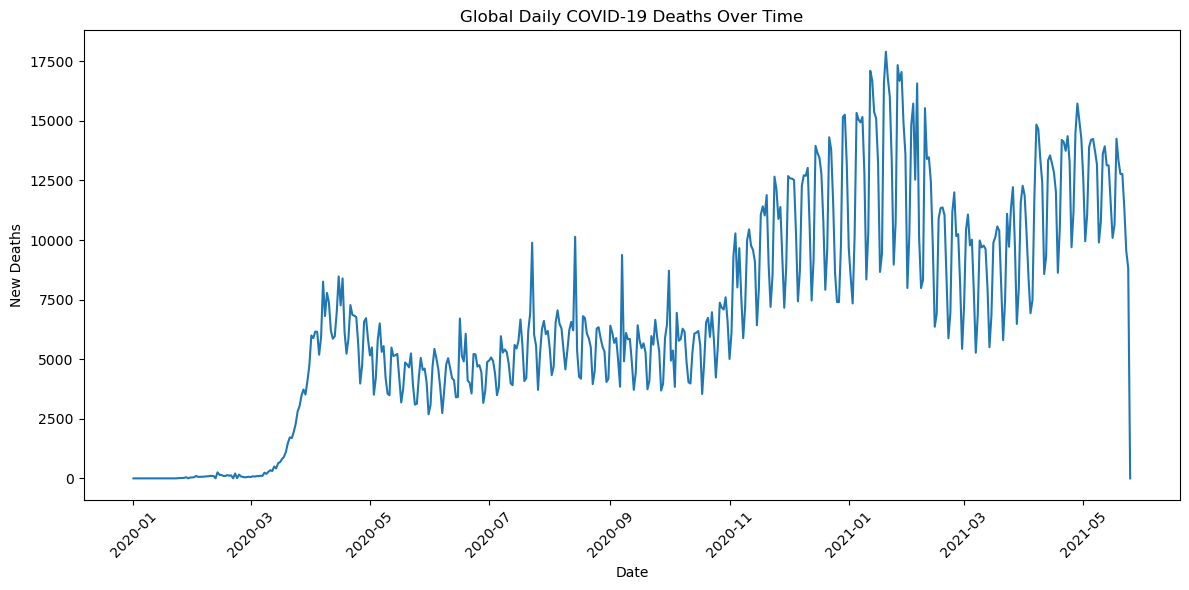

In [54]:
plt.figure(figsize=(12, 6))

plt.plot(
    global_daily["date"],
    global_daily["new_deaths"]
)

plt.title("Global Daily COVID-19 Deaths Over Time")
plt.xlabel("Date")
plt.ylabel("New Deaths")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Top 10 Countries by Total COVID-19 Cases

In [55]:
latest_data = covid_df.sort_values("date").groupby(
    "location"
).tail(1)

top_cases = latest_data.nlargest(
    10,
    "total_cases"
)[["location", "total_cases"]]

print(top_cases)

             location  total_cases
82927   United States   33143662.0
36183           India   26948874.0
11092          Brazil   16120756.0
28072          France    5667331.0
80469          Turkey    5194010.0
64651          Russia    4952412.0
82438  United Kingdom    4480760.0
39069           Italy    4194672.0
29987         Germany    3659990.0
73690           Spain    3647520.0


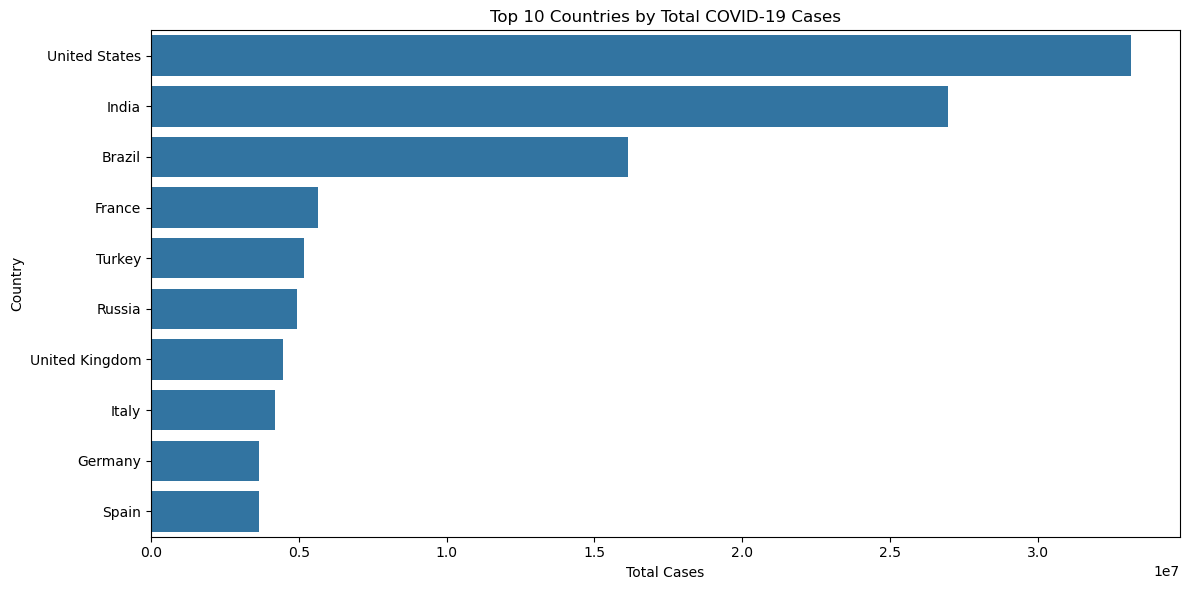

In [56]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_cases,
    x="total_cases",
    y="location"
)

plt.title("Top 10 Countries by Total COVID-19 Cases")
plt.xlabel("Total Cases")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

### Top 10 Countries by Total COVID-19 Deaths

In [57]:
top_deaths = latest_data.nlargest(
    10,
    "total_deaths"
)[["location", "total_deaths"]]

print(top_deaths)

             location  total_deaths
82927   United States      590320.0
11092          Brazil      449858.0
36183           India      307231.0
51053          Mexico      221695.0
82438  United Kingdom      127986.0
39069           Italy      125335.0
64651          Russia      116812.0
28072          France      108819.0
29987         Germany       87461.0
17089        Colombia       85207.0


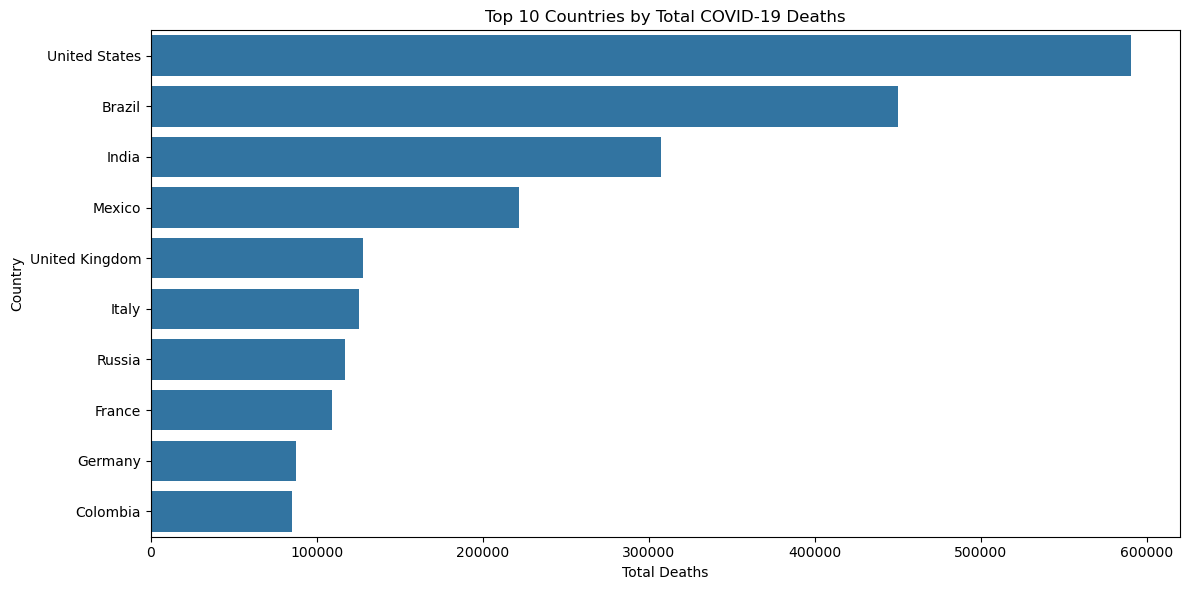

In [58]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_deaths,
    x="total_deaths",
    y="location"
)

plt.title("Top 10 Countries by Total COVID-19 Deaths")
plt.xlabel("Total Deaths")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

### Top 10 Countries by Death Rate

In [59]:
death_rate_data = latest_data[
    latest_data["total_cases"] >= 10000
].dropna(subset=["death_rate"])

In [60]:
top_death_rate = death_rate_data.nlargest(
    10,
    "death_rate"
)[["location", "total_cases", "total_deaths", "death_rate"]]

print(top_death_rate)

                     location  total_cases  total_deaths  death_rate
51053                  Mexico    2397307.0      221695.0    9.247668
74613                   Sudan      34889.0        2600.0    7.452206
76413                   Syria      24187.0        1740.0    7.193947
23791                   Egypt     254984.0       14766.0    5.790952
71833                 Somalia      14632.0         767.0    5.241935
16644                   China      91057.0        4636.0    5.091316
23325                 Ecuador     419198.0       20210.0    4.821111
10217  Bosnia and Herzegovina     203391.0        9150.0    4.498724
455               Afghanistan      66275.0        2812.0    4.242927
11977                Bulgaria     416727.0       17513.0    4.202511


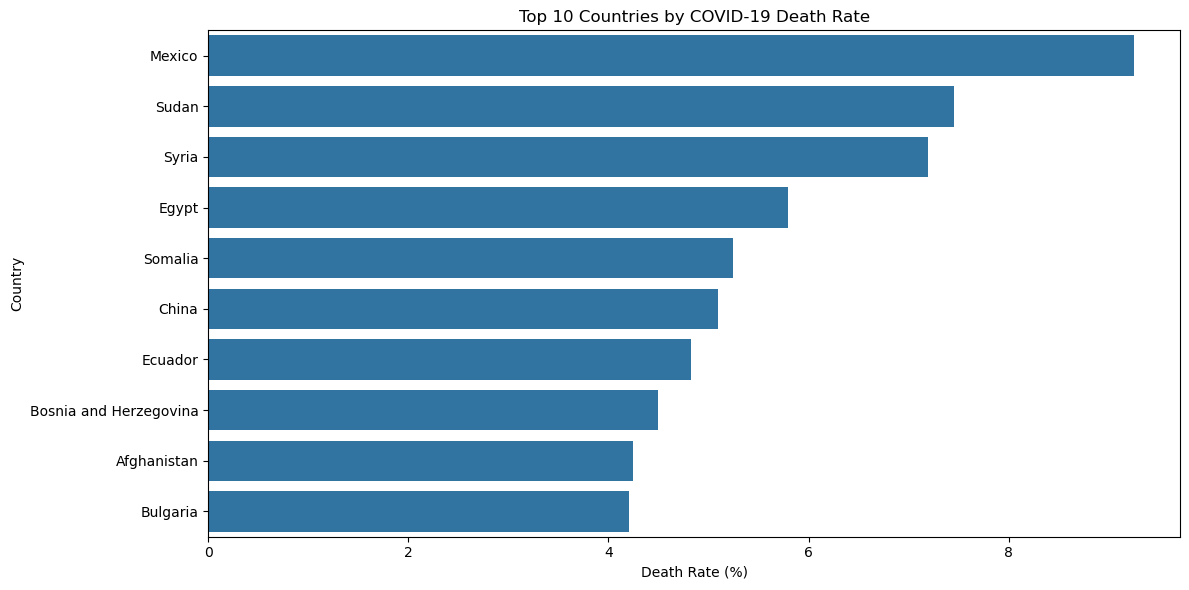

In [61]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_death_rate,
    x="death_rate",
    y="location"
)

plt.title("Top 10 Countries by COVID-19 Death Rate")
plt.xlabel("Death Rate (%)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

### Top 10 Countries by Vaccination Rate

In [62]:
vaccination_data = latest_data.dropna(
    subset=["vaccination_rate", "people_fully_vaccinated", "population"]
)

top_vaccination_rate = vaccination_data.nlargest(
    10,
    "vaccination_rate"
)[
    [
        "location",
        "people_fully_vaccinated",
        "population",
        "vaccination_rate"
    ]
]

print(top_vaccination_rate)

               location  people_fully_vaccinated   population  \
30557         Gibraltar                  37199.0      33691.0   
14830    Cayman Islands                  41245.0      65720.0   
65180      Saint Helena                   3528.0       6071.0   
26622  Falkland Islands                   1775.0       3483.0   
8885            Bermuda                  31251.0      62273.0   
3803              Aruba                  48208.0     106766.0   
6084            Bahrain                 716760.0    1701583.0   
40065            Jersey                  40455.0     101073.0   
82927     United States              130615797.0  331002647.0   
19751           Curacao                  61757.0     164100.0   

       vaccination_rate  
30557        110.412276  
14830         62.758673  
65180         58.112337  
26622         50.961815  
8885          50.183868  
3803          45.152951  
6084          42.123129  
40065         40.025526  
82927         39.460650  
19751         37.633760 

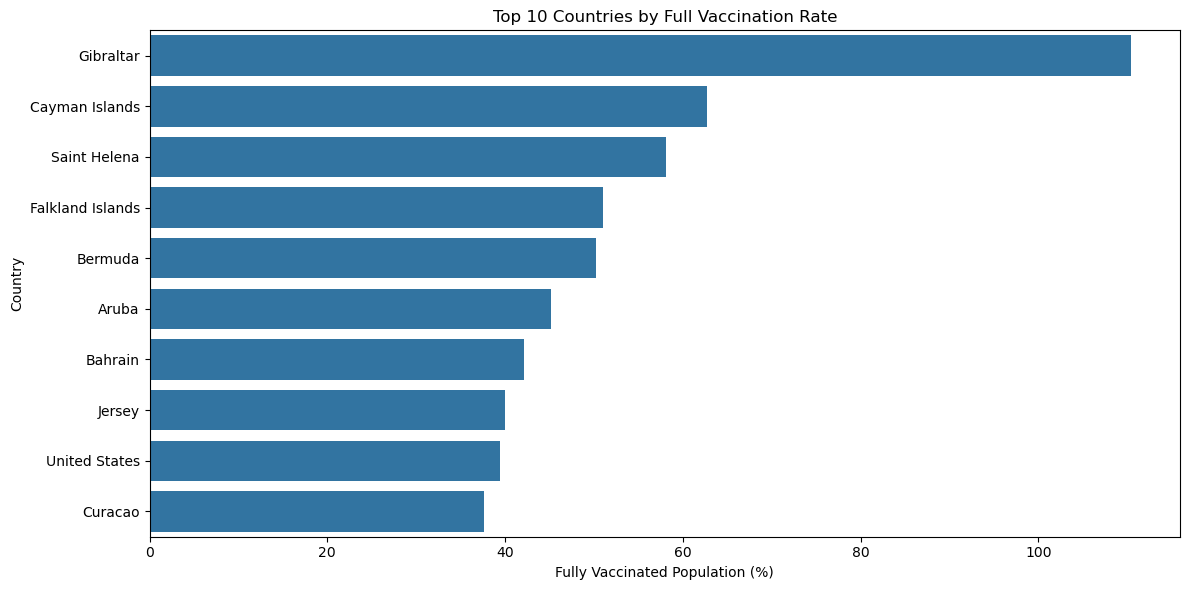

In [63]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_vaccination_rate,
    x="vaccination_rate",
    y="location"
)

plt.title("Top 10 Countries by Full Vaccination Rate")
plt.xlabel("Fully Vaccinated Population (%)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

### Top 10 Countries by Cases per 100,000 Population

In [64]:
cases_per_population = latest_data.dropna(
    subset=["cases_per_100k"]
)

top_cases_per_100k = cases_per_population.nlargest(
    10,
    "cases_per_100k"
)[["location", "total_cases", "population", "cases_per_100k"]]

print(top_cases_per_100k)

         location  total_cases  population  cases_per_100k
1814      Andorra      13569.0     77265.0    17561.638517
52946  Montenegro      99291.0    628062.0    15809.108018
20645     Czechia    1658092.0  10708982.0    15483.189719
67121  San Marino       5089.0     33938.0    14994.990866
6084      Bahrain     220847.0   1701583.0    12978.914340
71173    Slovenia     251773.0   2078932.0    12110.689527
46676  Luxembourg      69545.0    625976.0    11109.850857
69327  Seychelles      10740.0     98340.0    10921.293472
48564    Maldives      57341.0    540542.0    10608.056358
75529      Sweden    1058341.0  10099270.0    10479.381183


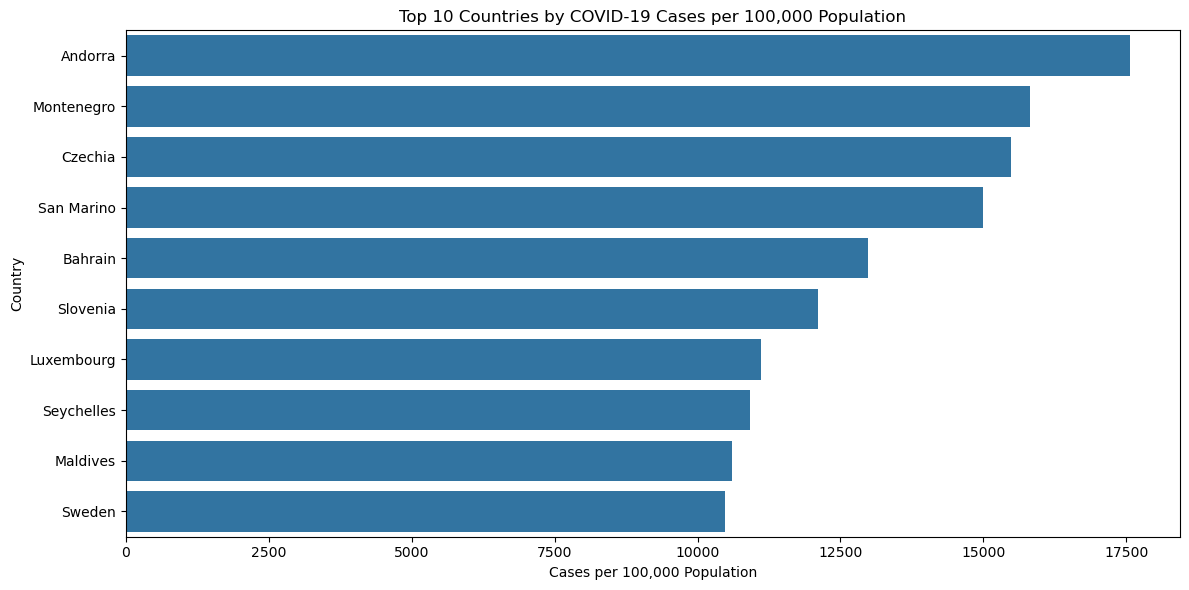

In [65]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_cases_per_100k,
    x="cases_per_100k",
    y="location"
)

plt.title("Top 10 Countries by COVID-19 Cases per 100,000 Population")
plt.xlabel("Cases per 100,000 Population")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

### Correlation Analysis

In [66]:
correlation_columns = [
    "total_cases",
    "total_deaths",
    "total_tests",
    "total_vaccinations",
    "people_fully_vaccinated",
    "population",
    "death_rate",
    "vaccination_rate",
    "cases_per_100k",
    "deaths_per_100k"
]

correlation_matrix = covid_df[correlation_columns].corr()

correlation_matrix

,total_cases,total_deaths,total_tests,total_vaccinations,people_fully_vaccinated,population,death_rate,vaccination_rate,cases_per_100k,deaths_per_100k
total_cases,1.000000,0.940157,0.960521,0.578383,0.798612,0.310888,-0.026509,0.110753,0.275953,0.308309
total_deaths,0.940157,1.000000,0.886879,0.520365,0.740517,0.276671,0.042938,0.080462,0.270382,0.389476
total_tests,0.960521,0.886879,1.000000,0.846303,0.796211,0.488860,-0.036023,0.141277,0.245673,0.238200
total_vaccinations,0.578383,0.520365,0.846303,1.000000,0.954851,0.628052,0.123993,0.162686,0.037353,0.045689
people_fully_vaccinated,0.798612,0.740517,0.796211,0.954851,1.000000,0.363372,-0.003929,0.208901,0.139989,0.129753
population,0.310888,0.276671,0.488860,0.628052,0.363372,1.000000,0.050839,-0.078614,-0.054186,-0.042783
death_rate,-0.026509,0.042938,-0.036023,0.123993,-0.003929,0.050839,1.000000,-0.230026,-0.147706,0.023616
vaccination_rate,0.110753,0.080462,0.141277,0.162686,0.208901,-0.078614,-0.230026,1.000000,0.408199,0.102292
cases_per_100k,0.275953,0.270382,0.245673,0.037353,0.139989,-0.054186,-0.147706,0.408199,1.000000,0.842589
deaths_per_100k,0.308309,0.389476,0.238200,0.045689,0.129753,-0.042783,0.023616,0.102292,0.842589,1.000000


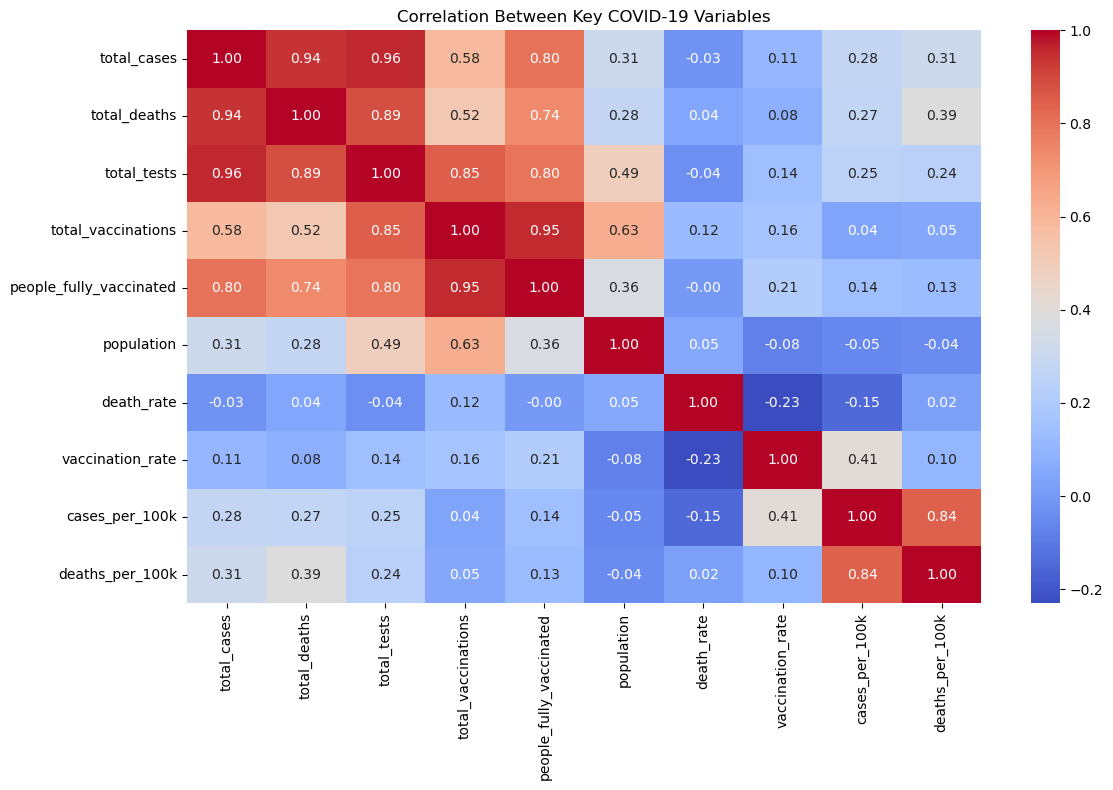

In [67]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Between Key COVID-19 Variables")

plt.tight_layout()
plt.show()

### Compare Cases and Deaths

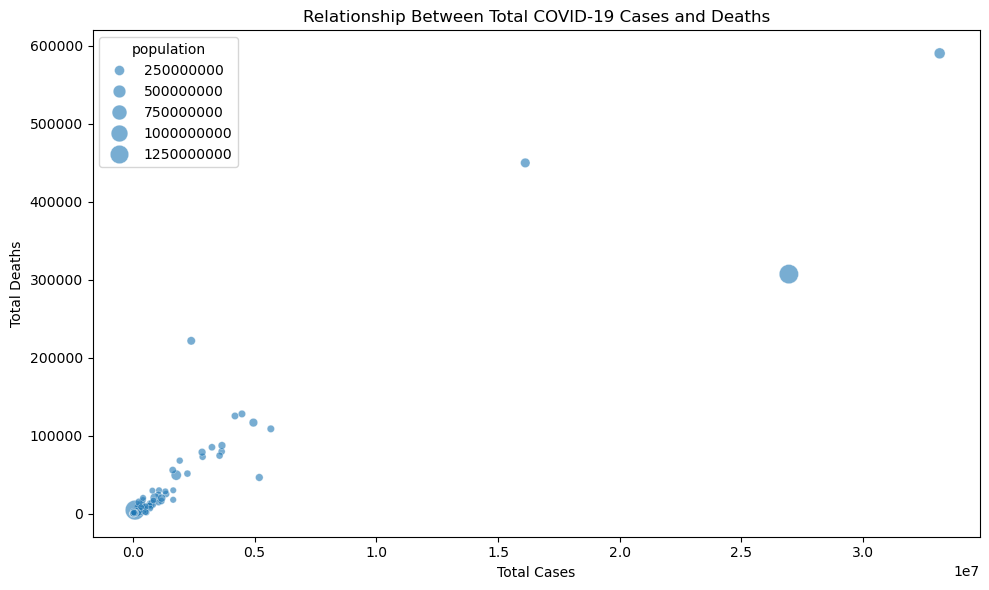

In [68]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=latest_data,
    x="total_cases",
    y="total_deaths",
    size="population",
    sizes=(20, 200),
    alpha=0.6
)

plt.title("Relationship Between Total COVID-19 Cases and Deaths")
plt.xlabel("Total Cases")
plt.ylabel("Total Deaths")

plt.tight_layout()
plt.show()

### Vaccination Rate vs Death Rate

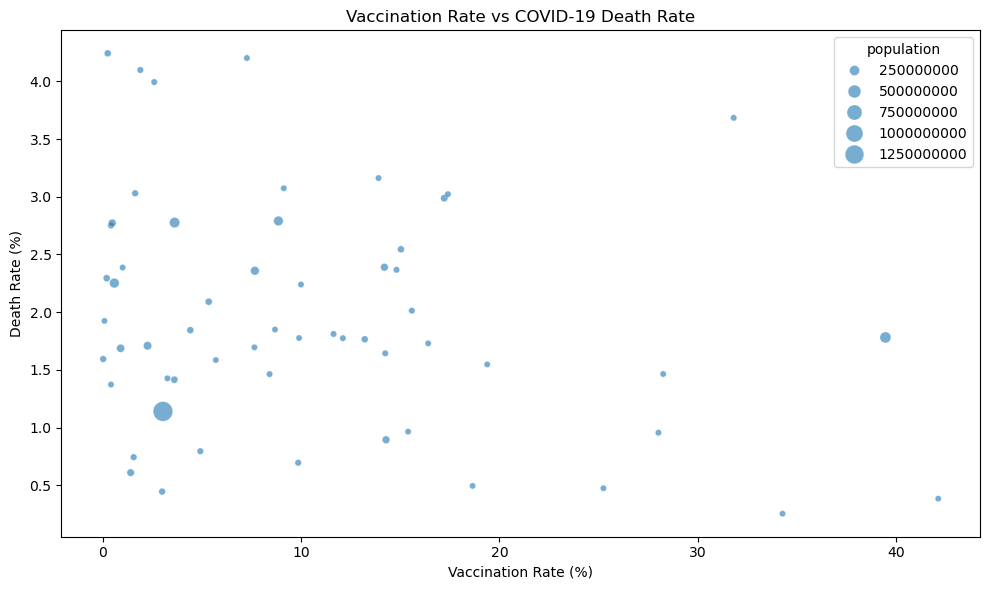

In [69]:
comparison_data = latest_data.dropna(
    subset=["vaccination_rate", "death_rate"]
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=comparison_data,
    x="vaccination_rate",
    y="death_rate",
    size="population",
    sizes=(20, 200),
    alpha=0.6
)

plt.title("Vaccination Rate vs COVID-19 Death Rate")
plt.xlabel("Vaccination Rate (%)")
plt.ylabel("Death Rate (%)")

plt.tight_layout()
plt.show()

### Continent-wise Analysis

In [70]:
continent_analysis = latest_data.groupby("continent").agg(
    total_cases=("total_cases", "sum"),
    total_deaths=("total_deaths", "sum"),
    average_death_rate=("death_rate", "mean"),
    average_vaccination_rate=("vaccination_rate", "mean")
).reset_index()

print(continent_analysis)

       continent  total_cases  total_deaths  average_death_rate  \
0         Africa    4765208.0      128677.0            2.185126   
1           Asia   48642674.0      645499.0            1.786316   
2         Europe   46514566.0     1064609.0            1.953779   
3  North America   38686114.0      870873.0            2.238363   
4        Oceania      48155.0        1097.0            6.342484   
5  South America   27819555.0      755860.0            2.604538   

   average_vaccination_rate  
0                 14.729105  
1                  8.019177  
2                 18.915709  
3                 25.388491  
4                 12.344802  
5                 19.201479  


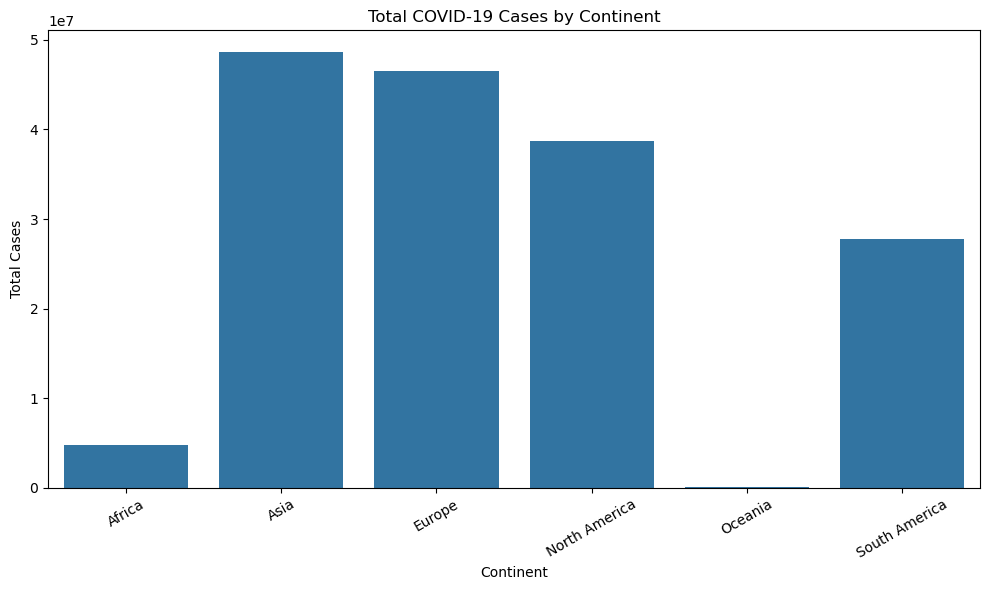

In [71]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=continent_analysis,
    x="continent",
    y="total_cases"
)

plt.title("Total COVID-19 Cases by Continent")
plt.xlabel("Continent")
plt.ylabel("Total Cases")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

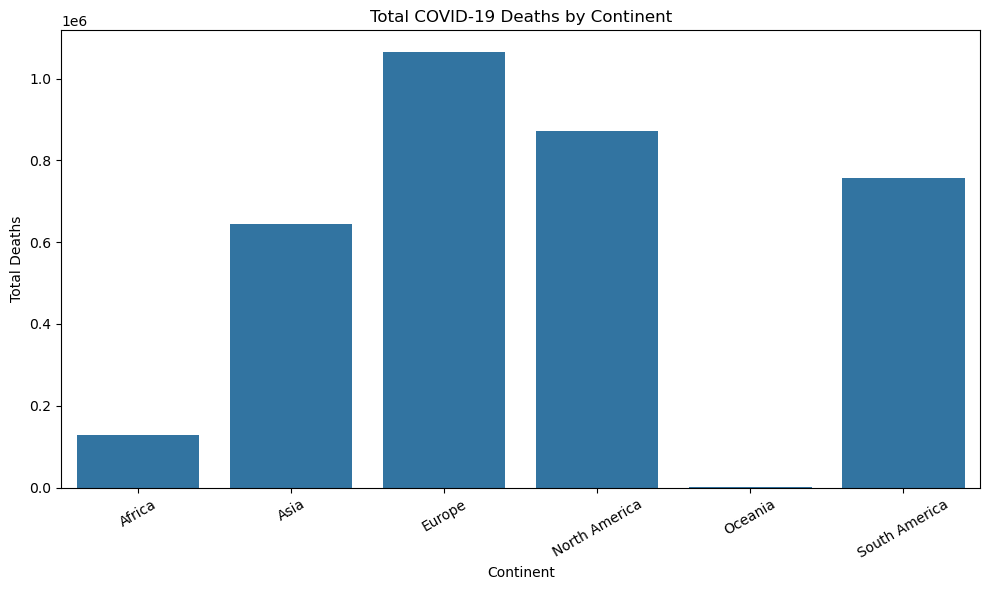

In [72]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=continent_analysis,
    x="continent",
    y="total_deaths"
)

plt.title("Total COVID-19 Deaths by Continent")
plt.xlabel("Continent")
plt.ylabel("Total Deaths")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Generate Key Insights Automatically

In [74]:
print("Top Country by Total Cases:")
print(top_cases.iloc[0])

print("\nTop Country by Total Deaths:")
print(top_deaths.iloc[0])

print("\nHighest Death Rate:")
print(top_death_rate.iloc[0])

print("\nHighest Vaccination Rate:")
print(top_vaccination_rate.iloc[0])

print("\nHighest Cases per 100,000:")
print(top_cases_per_100k.iloc[0])


Top Country by Total Cases:
location       United States
total_cases       33143662.0
Name: 82927, dtype: object

Top Country by Total Deaths:
location        United States
total_deaths         590320.0
Name: 82927, dtype: object

Highest Death Rate:
location           Mexico
total_cases     2397307.0
total_deaths     221695.0
death_rate       9.247668
Name: 51053, dtype: object

Highest Vaccination Rate:
location                    Gibraltar
people_fully_vaccinated       37199.0
population                    33691.0
vaccination_rate           110.412276
Name: 30557, dtype: object

Highest Cases per 100,000:
location               Andorra
total_cases            13569.0
population             77265.0
cases_per_100k    17561.638517
Name: 1814, dtype: object


### Save Your Cleaned Dataset

In [76]:
covid_df.to_csv(
    r"C:\Users\HP\OneDrive\Documents\My Projects\COVID-19-Data-Analysis\covid-data.xlsx",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
